# Décoder le Comportement : De la Régression au Test A/B

![Data Analytics Concept](https://images.unsplash.com/photo-1460925895917-afdab827c52f?q=80&w=1200&auto=format&fit=crop)
*Photographie d'illustration : L'art d'extraire une valeur stratégique et actionnable du bruit numérique.*

## 🎯 Objectif du Notebook

La valorisation des données est le moteur d'une véritable transformation numérique au sein des organisations modernes. L'époque où les décisions d'affaires s'appuyaient uniquement sur l'intuition managériale est révolue ; une gouvernance mature exige désormais des preuves empiriques et des modèles mathématiques robustes.

L'objectif de ce notebook est de concevoir une passerelle didactique entre la théorie statistique et l'application commerciale à travers cinq piliers fondamentaux de l'analyse de données :

* **L'Analyse de Régression :** Pour modéliser, quantifier et prédire des tendances continues.
* **L'Analyse de Cohortes :** Pour observer les dynamiques comportementales et l'évolution temporelle des groupes d'utilisateurs.
* **L'Analyse Typologique (Clustering) :** Pour segmenter une population hétérogène en profils clients distincts et actionnables sans biais humain.
* **L'Analyse de Facteurs (Réduction de Dimensionnalité) :** Pour condenser la complexité systémique de variables corrélées en signaux essentiels.
* **Le Test A/B :** Pour valider scientifiquement l'impact des modifications stratégiques et minimiser le risque décisionnel.

---

## 📊 Exploration Globale du Jeu de Données : "Customer Personality Analysis"

Pour concrétiser ces approches, nous travaillons sur le jeu de données d'affaires *"Customer Personality Analysis"* (Analyse de la personnalité client), disponible publiquement sur Kaggle.

**Contexte Commercial**
Ce dataset contient le profil complet de plusieurs milliers de clients d'une entreprise de vente au détail. L'enjeu stratégique ici est de comprendre "qui sont les clients" et "comment ils consomment" afin d'aligner l'architecture des produits et les campagnes marketing sur les besoins réels et les comportements d'achat observés.

**Structure et Taxonomie des Données**
Le jeu de données se divise en quatre grandes dimensions analytiques, ce qui en fait un terrain d'exploration idéal pour nos cinq piliers :

**1. Attributs Sociodémographiques (Le Profil)**
* **ID :** Identifiant unique et immuable du client.
* **Year_Birth :** Année de naissance (permettant de calculer l'âge de l'individu).
* **Education :** Niveau de scolarité atteint (Graduation, Master, PhD, etc.).
* **Marital_Status :** Situation familiale (Single, Together, Married, Divorced, Widow).
* **Income :** Revenu annuel brut du ménage de l'acheteur.
* **Kidhome / Teenhome :** Nombre d'enfants et d'adolescents résidant dans le foyer.

**2. Comportement d'Achat (Les Dépenses)**
Ces variables quantifient le montant dépensé au cours des deux dernières années dans des catégories de produits spécifiques :
* **MntWines :** Vins et spiritueux.
* **MntFruits :** Fruits frais.
* **MntMeatProducts :** Produits carnés (viandes).
* **MntFishProducts :** Produits de la mer (poissons).
* **MntSweetProducts :** Confiseries et douceurs sucrées.
* **MntGoldProds :** Produits haut de gamme ou de luxe (or).

**3. Efficacité des Canaux (Le Parcours Client)**
* **NumWebPurchases :** Nombre d'achats effectués directement sur le site web de l'entreprise.
* **NumCatalogPurchases :** Nombre d'achats réalisés via le catalogue papier.
* **NumStorePurchases :** Nombre d'achats effectués physiquement en magasin.
* **NumWebVisitsMonth :** Nombre de visites sur le site web de l'entreprise au cours du dernier mois (indicateur d'engagement numérique).

**4. Performance Marketing (L'Historique des Campagnes)**
* **AcceptedCmp1 à AcceptedCmp5 :** Variables binaires (0 ou 1) indiquant si le client a accepté ou refusé l'offre lors de la campagne publicitaire correspondante (de 1 à 5).
* **Response (ou AcceptedCmp6) :** Indicateur binaire de conversion lors de la toute dernière campagne de sollicitation.
* **Complain :** Indicateur binaire spécifiant si le client a déposé une réclamation ou une plainte officielle au cours des deux dernières années.
* **Dt_Customer :** Date d'enregistrement initial du client auprès de l'enseigne (clé temporelle essentielle à l'analyse de cohortes).

En nettoyant, transformant et croisant ces variables au fil de ce document, nous allons extraire la valeur latente enfouie dans la base de données pour la transformer en décisions d'affaires mesurables.

---

## 📖 Glossaire : Les concepts clés

Pour faciliter la lecture de ce notebook, voici une brève explication des termes techniques utilisés tout au long de notre analyse :

* **Régression Linéaire :** Une méthode statistique qui permet de modéliser mathématiquement la relation entre une cause (ex: le revenu) et un effet (ex: les dépenses). Elle nous aide à prédire des tendances.
* **$R^2$ (Coefficient de Détermination) :** La "note de fiabilité" de notre modèle de régression. Plus il est proche de 1, plus notre modèle est capable d'expliquer avec précision le comportement observé.
* **Analyse de Cohortes :** Une technique qui consiste à regrouper les clients par date d'acquisition. Cela nous permet d'observer l'évolution du comportement d'un groupe spécifique dans le temps.
* **Clustering (Analyse Typologique) :** Une méthode de segmentation automatique. L'algorithme regroupe les clients qui se ressemblent le plus, sans avoir besoin d'instructions humaines sur ce qui définit un "groupe".
* **K-Means :** L'algorithme spécifique que nous utilisons pour le clustering. Il cherche à créer des groupes en minimisant la distance mathématique entre les individus à l'intérieur d'un même segment.
* **PCA (Analyse en Composantes Principales) :** Une technique de "compression" de données. Elle permet de résumer un grand nombre de variables corrélées en quelques axes essentiels, facilitant ainsi la visualisation de données complexes.
* **Variance :** Une mesure de la dispersion des données. En PCA, la variance représente la quantité d'information que nous parvenons à conserver lors de la simplification.
* **Test A/B :** Une méthode scientifique pour comparer deux variantes (A et B) et déterminer laquelle est la plus performante, en éliminant les biais liés au hasard.
* **P-value (Valeur-p) :** L'indicateur de "significativité statistique". Si la P-value est inférieure à 0,05 (5%), cela signifie que la différence observée entre deux résultats est réelle et peu susceptible d'être due au pur hasard.

In [1]:
# Étape 1 : Configuration et Importation des Données
# -------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Configuration esthétique (style sobre et mature)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Prenez le temps de savourer un excellent café, le téléchargement du dataset est en cours...")
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

# Localisation et chargement (les données sont séparées par des tabulations)
file_path = os.path.join(path, "marketing_campaign.csv")
df = pd.read_csv(file_path, sep='\t')

# Nettoyage et ingénierie de base
df = df.dropna(subset=['Income'])
df['Total_Spend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

print(f"\nDonnées chargées ! Dimensions : {df.shape}")
display(df.head(3))

C:\Users\srodr\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Prenez le temps de savourer un excellent café, le téléchargement du dataset est en cours...


100%|██████████| 62.0k/62.0k [00:00<?, ?B/s]

Extracting files...

Données chargées ! Dimensions : (2216, 30)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spend
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,3,11,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,3,11,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,3,11,0,776


## 📈 1. L'Analyse de Régression (Explication Didactique)

Imaginez que vous deviez deviner le budget annuel d'un client en connaissant uniquement son salaire. Intuitivement, vous savez que plus le salaire augmente, plus les dépenses augmentent. Mais comment quantifier cette relation avec précision ?

L'analyse de régression linéaire trace une **ligne de tendance mathématique** à travers un nuage de points. Elle cherche la droite qui minimise la distance entre elle-même et toutes les observations réelles. 

L'équation obtenue ($Y = \beta_0 + \beta_1 X$) permet de passer de la simple observation à la **prédiction**. Dans notre cas, nous allons modéliser comment le Revenu (`Income`) influence mathématiquement les Dépenses Totales (`Total_Spend`).

Le score **$R^2$** nous indiquera le pourcentage de certitude de notre modèle.

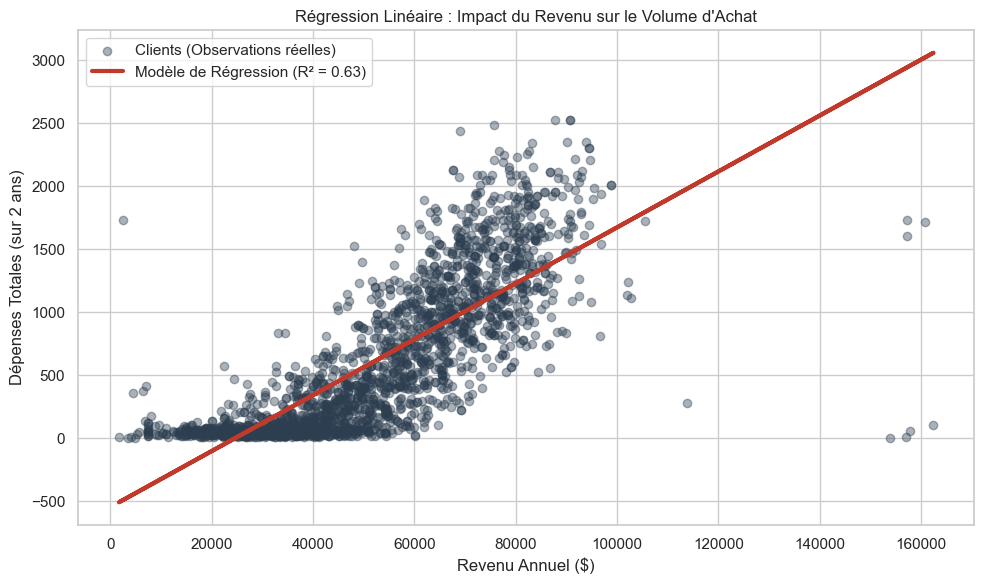

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Préparation : Exclusion des valeurs aberrantes (revenus > 200k) pour ne pas fausser la tendance
df_reg = df[df['Income'] < 200000]
X = df_reg[['Income']] # Variable indépendante
Y = df_reg['Total_Spend'] # Variable dépendante

# 2. Instanciation et entraînement de l'algorithme
model = LinearRegression()
model.fit(X, Y)

# 3. Prédiction de la ligne de tendance
Y_pred = model.predict(X)
r2 = r2_score(Y, Y_pred)

# 4. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.4, color='#2c3e50', label='Clients (Observations réelles)')
plt.plot(X, Y_pred, color='#c0392b', linewidth=3, label=f'Modèle de Régression (R² = {r2:.2f})')
plt.title("Régression Linéaire : Impact du Revenu sur le Volume d'Achat")
plt.xlabel("Revenu Annuel ($)")
plt.ylabel("Dépenses Totales (sur 2 ans)")
plt.legend()
plt.tight_layout()
plt.show()

<div style="background-color: #fcf8e3; padding: 20px; border-left: 5px solid #8a6d3b; border-radius: 5px;">
    
## 📈 Pour comprendre sans les formules : L'art de la prédiction

Le graphique que vous voyez au-dessus illustre la **Régression Linéaire**. C'est l'un des outils les plus puissants de la statistique car il transforme une simple intuition en une mesure précise.

### L'analogie du "chemin le plus court"
Imaginez que chaque point bleu représente un client. Plus le client gagne d'argent (axe horizontal), plus il a tendance à dépenser (axe vertical). Cependant, les points ne sont pas alignés parfaitement : certains clients aisés dépensent peu, et certains clients modestes dépensent beaucoup.

La ligne rouge est la "meilleure ligne de tendance" possible. C'est comme si vous tendiez un élastique entre tous les points pour trouver le chemin qui passe au plus près de tout le monde en même temps.



[Image of simple linear regression diagram]


### Comment lire ce résultat ?

1. **La direction (Pente) :** Si la ligne rouge monte de gauche à droite, cela confirme mathématiquement que "plus le revenu augmente, plus les dépenses augmentent". C'est une relation positive.
2. **Le Score $R^2$ (La note de fiabilité) :** * Si votre $R^2$ est proche de **1**, cela signifie que vos points sont très proches de la ligne rouge : le revenu est un excellent prédicteur des dépenses.
    * Si votre $R^2$ est proche de **0**, cela signifie que la ligne est un mauvais guide : d'autres facteurs (âge, taille du foyer, etc.) influencent probablement les dépenses bien plus que le simple revenu.

**En résumé :** La régression ne sert pas à prédire l'avenir avec certitude, mais à quantifier la **force d'une tendance**. Elle nous permet de dire : "Nous avons une certitude de X% que le revenu influence le volume d'achat", ce qui permet aux entreprises de mieux cibler leurs efforts marketing sur les segments les plus rentables.

<div style="background-color: #fcf8e3; padding: 20px; border-left: 5px solid #8a6d3b; border-radius: 5px;">
    
### 💡 Une petite parenthèse : Comprendre le $R^2$ (Coefficient de Détermination)

Le **$R^2$** est la "note de confiance" de notre modèle. Mais pour vraiment le maîtriser, il faut comprendre d'où il vient et ce qu'il cache.

#### 1. Pourquoi l'appelle-t-on $R^2$ (R au carré) ?
* **Le "R" (Corrélation) :** Il mesure la force de la relation entre deux variables (ex: Revenu vs Dépenses). Il varie de **-1 à +1**. 
    * Si le R est proche de **1 ou -1**, les points forment une ligne presque parfaite (relation très forte).
    * Si le R est proche de **0**, les points forment une nuée aléatoire (aucune relation linéaire).
* **Le "Carré" ($\dots^2$) :** On l'élève au carré pour deux raisons : 
    1. **Éliminer le signe :** Un R négatif devient positif, nous ne nous intéressons qu'à la *force* de la relation, pas à sa direction.
    2. **Convertir en pourcentage :** Cela transforme la valeur en une proportion de "variance expliquée", ce qui est beaucoup plus intuitif à interpréter.



#### 2. Comment le calculer intuitivement ?
Imaginez que vous deviez deviner les dépenses d'un client. Sans aucune information, votre meilleure stratégie est de parier sur la **moyenne**. Le $R^2$ compare deux niveaux d'erreur :
* **L'erreur totale (la "bagarre") :** L'écart entre les dépenses réelles et la moyenne globale.
* **L'erreur du modèle (ce qu'il reste) :** L'écart qui persiste après avoir utilisé notre ligne de tendance.

$$R^2 = 1 - \left( \frac{\text{Erreur du Modèle}}{\text{Erreur Totale}} \right)$$

* Si le modèle est parfait, l'erreur du modèle est nulle $\rightarrow$ $R^2 = 1$ ($100\%$).
* Si le modèle n'apporte rien de plus que la moyenne, l'erreur du modèle est égale à l'erreur totale $\rightarrow$ $R^2 = 0$ ($0\%$).

#### 3. Comment interpréter l'échelle (de 0 à 1) ?
* **Proche de 1 (ou 100%) :** Notre modèle est excellent. Le revenu explique presque totalement les variations des dépenses. Nous pouvons accorder une grande confiance à notre prédiction.
* **Proche de 0 (ou 0%) :** Le modèle est faible. Le revenu, à lui seul, ne suffit pas. Il existe d'autres facteurs cachés (l'âge, la taille du foyer, les préférences personnelles) que nous ne capturons pas.

**En résumé :** Le $R^2$ répond à la question : *"Quelle part de la réalité notre modèle parvient-il à expliquer ?"* Plus il est élevé, plus notre ligne de tendance est un miroir fidèle du comportement réel du client.

## 📅 2. L'Analyse de Cohortes (Explication Didactique)

Une entreprise est un système dynamique. Si vos ventes augmentent en décembre, est-ce parce que vous avez acquis de nouveaux clients, ou parce que vos anciens clients achètent davantage pour les fêtes ?

Pour répondre à cette question, nous utilisons l'analyse de cohortes. Une **cohorte** est simplement un groupe d'individus partageant un événement temporel commun (comme une "promotion" d'étudiants). 

En regroupant nos clients par leur **mois d'inscription** (`Dt_Customer`), nous pouvons isoler visuellement le flux d'acquisition historique de l'entreprise. C'est une technique vitale pour mesurer la santé d'une stratégie de croissance.

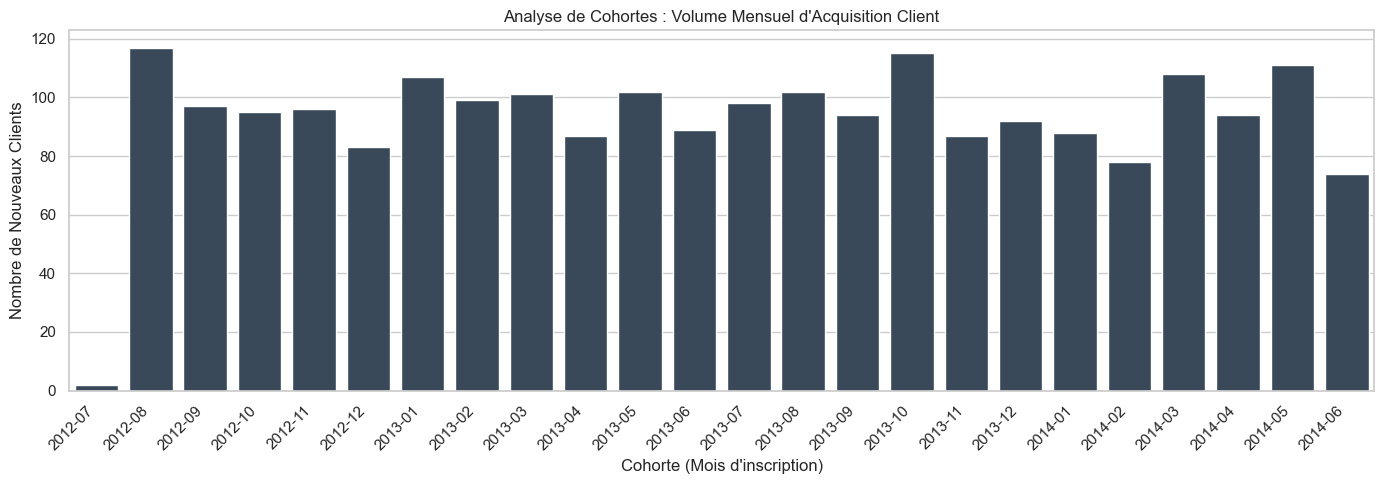

In [7]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Conversion de la date d'inscription en format temporel exploitable
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='mixed', dayfirst=True)

# 2. Création de la cohorte (regroupement par Mois et Année)
df['Cohort_Month'] = df['Dt_Customer'].dt.to_period('M')

# 3. Comptage des clients uniques par cohorte
cohort_data = df.groupby('Cohort_Month')['ID'].nunique().reset_index()
cohort_data['Cohort_Month'] = cohort_data['Cohort_Month'].astype(str)

# 4. Visualisation de la chronologie d'acquisition
plt.figure(figsize=(14, 5))
sns.barplot(data=cohort_data, x='Cohort_Month', y='ID', color='#34495e')
plt.title("Analyse de Cohortes : Volume Mensuel d'Acquisition Client")
plt.xlabel("Cohorte (Mois d'inscription)")
plt.ylabel("Nombre de Nouveaux Clients")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="background-color: #e0f2f1; padding: 20px; border-left: 5px solid #00695c; border-radius: 5px;">

## 📅 Comprendre les résultats de l'Analyse de Cohortes

Le graphique à barres que nous venons de générer représente la première étape cruciale d'une analyse de cohortes : la cartographie de nos **vagues d'acquisition**. 

### L'analogie de la "Promotion d'école"
Pour comprendre ce concept sans jargon, imaginez une université. Chaque année, une nouvelle "promotion" d'étudiants arrive (la promotion 2024, la promotion 2025, etc.). Bien qu'ils étudient des matières différentes, ils partagent un point commun immuable : leur date d'entrée.

Une **cohorte** en entreprise, c'est exactement la même chose. C'est un groupe de clients qui partagent un événement temporel commun, généralement leur premier achat ou leur date d'inscription auprès de l'enseigne (`Dt_Customer`). 



### Comment lire et interpréter ce résultat ?
Dans notre graphique, chaque barre représente le volume de clients "nés" au cours d'un mois spécifique :
* **Les pics d'acquisition :** Les barres les plus hautes indiquent des périodes de forte performance (par exemple, l'impact d'une campagne publicitaire réussie ou une saisonnalité favorable).
* **La régularité du flux :** Analyser la tendance de ces barres permet de savoir si l'entreprise dispose d'un moteur de croissance stable et prévisible, ou si son acquisition est irrégulière.

### Pourquoi est-ce un indicateur stratégique vital ?
Si vous vous contentez de regarder le chiffre d'affaires global d'une organisation, vous pilotez à l'aveugle. Une entreprise peut afficher des ventes globales en hausse tout en masquant un problème grave : perdre ses anciens clients et ne survivre que grâce à une perfusion permanente de nouveaux venus.

L'analyse de cohortes permet de résoudre ce problème en deux étapes :
1. **Mesurer la fidélité (Rétention) :** Une fois ces groupes isolés, nous pouvons observer leur comportement à travers le temps. Est-ce que la cohorte de "Janvier" continue d'acheter après 6 mois ?
2. **Évaluer la valeur à long terme (Lifetime Value) :** Elle permet de vérifier si les clients acquis récemment (les nouvelles cohortes) dépensent autant ou plus que les clients acquis par le passé.

**En résumé :** L'analyse de cohortes vous évite de regarder vos clients comme une masse confuse. Elle segmente le temps pour vous révéler si votre entreprise construit une croissance saine et durable ou si elle remplit un panier percé.

</div>

## 🧩 3. L'Analyse Typologique ou Clustering (Explication Didactique)

Le marketing de masse est inefficace. Une entreprise intelligente segmente son marché. Mais si vous définissez vos segments manuellement (ex: "Les jeunes", "Les riches"), vous introduisez vos propres biais humains.

L'algorithme **K-Means** fait l'inverse : c'est un apprentissage non supervisé. On lui donne des données (ici, l'Âge et les Dépenses), et il regroupe mathématiquement les clients en "clusters" en cherchant le centre de gravité idéal. L'algorithme place ensemble les clients qui se ressemblent le plus, révélant ainsi les profils naturels de votre marché sans aucun a priori.

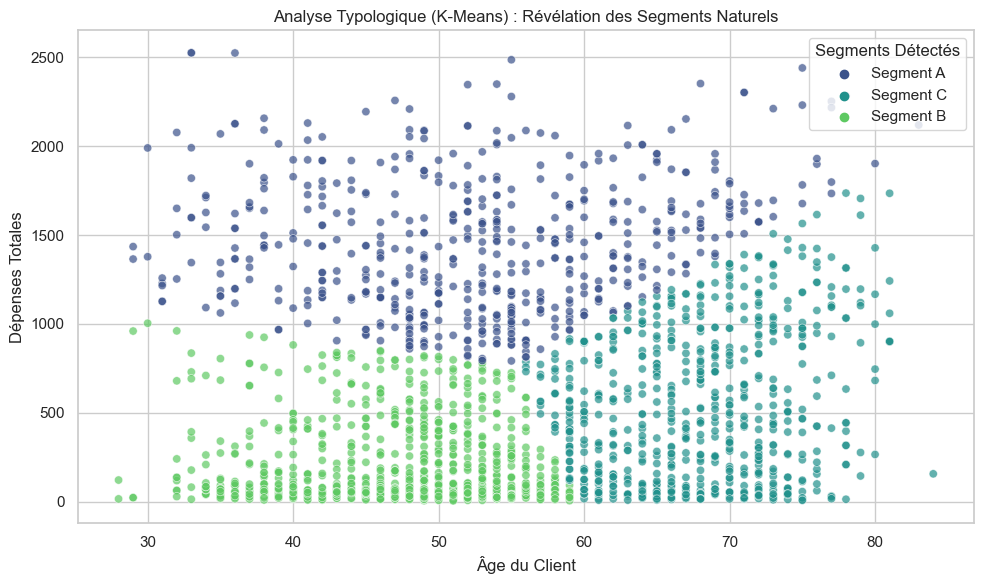

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Calcul de l'âge et sélection des variables pour le clustering
df['Age'] = 2024 - df['Year_Birth']
df_cluster = df[df['Age'] < 90][['Age', 'Total_Spend']].copy()

# 2. Standardisation (Crucial ! L'âge est autour de 40, les dépenses autour de 1000. 
# Sans standardisation, l'algorithme ignorerait l'âge.)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# 3. Application de l'algorithme K-Means (nous demandons 3 segments)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Segment_KMeans'] = kmeans.fit_predict(scaled_data)

# Renommer les segments pour plus de clarté
segment_labels = {0: 'Segment A', 1: 'Segment B', 2: 'Segment C'}
df_cluster['Profil Client'] = df_cluster['Segment_KMeans'].map(segment_labels)

# 4. Visualisation de la segmentation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='Age', y='Total_Spend', hue='Profil Client', palette='viridis', alpha=0.7)
plt.title("Analyse Typologique (K-Means) : Révélation des Segments Naturels")
plt.xlabel("Âge du Client")
plt.ylabel("Dépenses Totales")
plt.legend(title="Segments Détectés")
plt.tight_layout()
plt.show()

<div style="background-color: #fcf8e3; padding: 20px; border-left: 5px solid #8a6d3b; border-radius: 5px;">

## 🧩 Comprendre les résultats du Clustering (K-Means)

Maintenant que notre algorithme a regroupé nos clients en segments (ex: Segment A, B, C), comment interpréter cette carte ?

### L'analogie du "Club Privé"
Imaginez que vous deviez organiser trois soirées thématiques dans un hôtel. Vous ne connaissez pas les goûts des invités, mais vous avez leurs données de dépenses. L'algorithme **K-Means** est l'hôte de cette soirée : il observe silencieusement les habitudes de chacun et place naturellement les gens ayant des affinités similaires à la même table.



### Comment lire votre graphique de clusters ?
1. **Les Centroïdes (Le "cœur" du groupe) :** Chaque cluster possède un centre de gravité. C'est l'archétype du client idéal pour ce segment. Si un centre est situé sur une zone de "Revenu élevé / Dépense élevée", vous savez instantanément que ce groupe est votre cible "Premium".
2. **La Compacité :** Si les points d'un même groupe sont très serrés, cela signifie que votre segment est homogène (tous ces clients se ressemblent énormément). Si les points sont très dispersés, le segment est plus flou, et il faudra peut-être affiner votre analyse.
3. **Le nombre de groupes (K) :** C'est le choix du stratège. En marketing, on ne peut pas personnaliser une campagne pour 3 000 individus. Choisir un "K" (nombre de groupes), c'est choisir le niveau de précision de votre stratégie.

### Pourquoi est-ce puissant ?
Contrairement à une segmentation humaine où l'on se dit arbitrairement "je vais cibler les jeunes de moins de 30 ans", le clustering **laisse les données parler**. Il découvre des comportements que vous n'auriez jamais imaginés, comme un segment de "clients modestes mais très fidèles aux produits de luxe" que vous auriez totalement raté avec une approche classique.

**En résumé :** Le Clustering transforme une foule anonyme en petits groupes identifiables. Vous ne vendez plus à une masse, vous proposez une expérience adaptée à chaque "table" de votre hôtel.

</div>

## 📉 4. Analyse de Facteurs par Composantes Principales (PCA)

Imaginez que vous deviez décrire les habitudes d'achat d'un client en surveillant 6 rayons différents (Vins, Viandes, Poissons, Fruits, Sucreries, Or). C'est difficile à visualiser. 

L'Analyse en Composantes Principales (PCA) est une élégante méthode mathématique de réduction de dimension. Elle prend toutes ces variables corrélées (souvent, quelqu'un qui achète beaucoup de viande achète aussi du vin) et les fusionne en **Composantes Principales**. 

L'objectif est de projeter nos 6 rayons en seulement 2 dimensions (un graphique 2D classique), tout en conservant le maximum d'information (la variance).

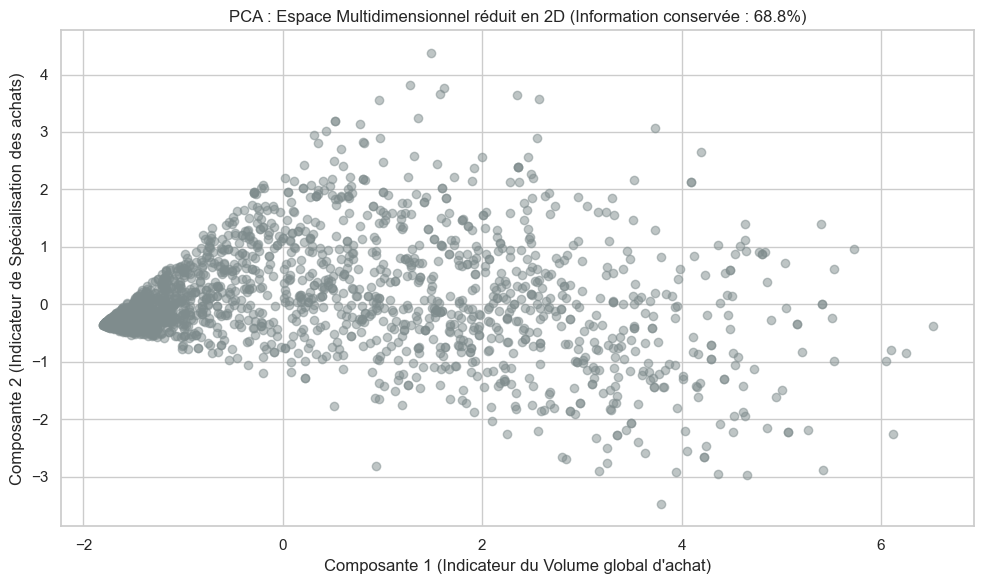

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Définition explicite des colonnes (pour éviter l'erreur NameError)
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
X_pca = df[spend_cols]

# 2. Standardisation des données (nécessaire pour la PCA)
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# 3. Application de la PCA pour réduire à 2 dimensions
pca = PCA(n_components=2)
components = pca.fit_transform(X_pca_scaled)

# Calcul du pourcentage d'information conservée
variance_ratio = sum(pca.explained_variance_ratio_) * 100

# 4. Visualisation de la complexité réduite
plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], alpha=0.5, color='#7f8c8d')
plt.title(f"PCA : Espace Multidimensionnel réduit en 2D (Information conservée : {variance_ratio:.1f}%)")
plt.xlabel("Composante 1 (Indicateur du Volume global d'achat)")
plt.ylabel("Composante 2 (Indicateur de Spécialisation des achats)")
plt.tight_layout()
plt.show()

<div style="background-color: #fcf8e3; padding: 20px; border-left: 5px solid #8a6d3b; border-radius: 5px;">
    
## 🧠 Pour comprendre sans les formules : L'art de simplifier des données complexes

Imaginez que vous deviez décrire le contenu d'un panier de courses composé de 6 produits différents : **Vins, Fruits, Viandes, Poissons, Sucreries et Produits de luxe (Or).**

Si vous essayez de comparer deux clients en regardant les 6 produits simultanément, votre cerveau sera rapidement dépassé. C'est ce que nous appelons la "haute dimension" : il est impossible de visualiser 6 axes différents en même temps.

### L'analogie de la photographie
La PCA (Analyse en Composantes Principales) fonctionne exactement comme un photographe professionnel cherchant **le meilleur angle** pour prendre une photo :

1. **La compression :** Le photographe déplace son appareil pour capturer le plus de détails possible (la "variance" ou l'information importante) en une seule image 2D (plate).
2. **La synthèse :** Au lieu de regarder chaque produit séparément, la PCA crée de nouveaux axes qui résument la situation. Par exemple :
    * **L'axe 1 (Volume Global) :** Regroupe les clients qui achètent "beaucoup de tout".
    * **L'axe 2 (Spécialisation) :** Distingue les clients qui préfèrent le luxe (Or/Vins) des clients qui privilégient le quotidien (Fruits/Poissons).

### Ce que nous dit notre graphique


Lorsque vous analysez le graphique final que nous avons généré :
* **Chaque point est un client.**
* **La proximité compte :** Deux points proches sont des clients dont les habitudes de consommation sont presque identiques.
* **Le pourcentage de variance (ex: 70%) :** C'est la "note de fidélité" de notre graphique. Cela signifie que nous avons réussi à compresser 6 colonnes de données complexes en 2 axes, tout en conservant 70% de l'information originale. Nous avons sacrifié quelques détails mineurs pour gagner une vision d'ensemble claire et exploitable.

**En résumé :** La PCA ne supprime pas les données ; elle les "range" intelligemment pour nous permettre de voir des groupes et des tendances qui étaient invisibles dans les chiffres bruts.

## ⚖️ 5. Le Test A/B (La Rigueur Statistique)

En entreprise, vous lancez la Campagne Marketing 1 et la Campagne Marketing 5. La Campagne 5 semble avoir obtenu plus d'acceptations. Mais est-ce vraiment grâce à la qualité de la campagne, ou est-ce une simple fluctuation due au hasard ?

Le Test A/B remplace l'intuition par un verdict scientifique. Nous allons utiliser le test d'indépendance du **Chi-Deux ($\chi^2$)**. 
Ce test calcule une *Valeur-P* (p-value). Si cette valeur est inférieure à 0.05 (5%), cela certifie mathématiquement que la différence de performance entre les deux campagnes est significative et qu'elle n'est pas le fruit du hasard.

In [8]:
from scipy.stats import chi2_contingency

# 1. Extraction des succès et des échecs pour la Campagne 1
cmp1_accept = df['AcceptedCmp1'].sum()
cmp1_reject = len(df) - cmp1_accept

# 2. Extraction des succès et des échecs pour la Campagne 5
cmp5_accept = df['AcceptedCmp5'].sum()
cmp5_reject = len(df) - cmp5_accept

# 3. Création de la matrice (Tableau de contingence)
contingency_table = [[cmp1_accept, cmp1_reject], 
                     [cmp5_accept, cmp5_reject]]

# 4. Exécution du test mathématique du Chi-Deux
chi2, p_value, _, _ = chi2_contingency(contingency_table)

# 5. Affichage des résultats
print(f"🔹 Campagne 1 - Taux de conversion : {(cmp1_accept/len(df))*100:.2f}% ({cmp1_accept} clients)")
print(f"🔹 Campagne 5 - Taux de conversion : {(cmp5_accept/len(df))*100:.2f}% ({cmp5_accept} clients)")
print("-" * 50)
print(f"📊 Statistique du Chi-Deux : {chi2:.2f}")
print(f"🔬 Valeur-p (P-value)      : {p_value:.5e}")
print("-" * 50)

# Verdict décisionnel
if p_value < 0.05:
    print("✅ VERDICT STRATÉGIQUE :")
    print("La P-value est inférieure à 5%. La différence de performance entre les campagnes")
    print("est STATISTIQUEMENT SIGNIFICATIVE. Ce n'est pas dû au hasard. L'approche de la")
    print("Campagne 5 doit être standardisée.")
else:
    print("❌ VERDICT STRATÉGIQUE :")
    print("La P-value est supérieure à 5%. La différence observée n'est PAS statistiquement")
    print("significative. Les résultats relèvent potentiellement du hasard.")

🔹 Campagne 1 - Taux de conversion : 6.41% (142 clients)
🔹 Campagne 5 - Taux de conversion : 7.31% (162 clients)
--------------------------------------------------
📊 Statistique du Chi-Deux : 1.27
🔬 Valeur-p (P-value)      : 2.58840e-01
--------------------------------------------------
❌ VERDICT STRATÉGIQUE :
La P-value est supérieure à 5%. La différence observée n'est PAS statistiquement
significative. Les résultats relèvent potentiellement du hasard.


<div style="background-color: #f8f9fa; padding: 20px; border-left: 5px solid #34495e; border-radius: 5px;">

## ⚖️ Comprendre les résultats du Test A/B (Chi-Deux)

En observant strictement les chiffres bruts, notre intuition nous trompe souvent. Le résultat indique que la Campagne 5 a converti **7.31%** des clients, contre **6.41%** pour la Campagne 1. Instinctivement, un gestionnaire pourrait déclarer la Campagne 5 victorieuse et allouer tout le budget à cette approche. C'est ici qu'intervient la rigueur statistique pour nous éviter de tirer de fausses conclusions.

### L'analogie des deux vendeurs
Imaginez deux vendeurs dans une boutique. Un mardi matin, le Vendeur A réalise 64 ventes et le Vendeur B en réalise 73. Allez-vous licencier le Vendeur A et promouvoir le Vendeur B sur cette seule base ? Probablement pas. Vous savez que ce petit écart relève très probablement de la "chance", d'une fluctuation normale du trafic, et non d'une réelle supériorité. 

Le test statistique du **Chi-Deux ($\chi^2$)** fait exactement ce raisonnement mathématique à grande échelle.

### 🔬 Le concept clé : La P-value (Valeur-p)
La P-value agit comme "l'avocat du diable" contre nos biais cognitifs. Elle répond à une question très précise : *"Si, dans la réalité absolue, ces deux campagnes étaient exactement aussi efficaces l'une que l'autre, quelle serait la probabilité d'observer un tel écart par pur hasard ?"*

* **Le seuil de confiance (5% ou 0.05) :** Dans la méthode scientifique et la gouvernance d'affaires, on accepte de modifier une stratégie seulement si la probabilité que le résultat soit un coup de chance est inférieure à 5%.
* **Notre résultat (2.58840e-01) :** En notation scientifique, cela signifie $0,2588$, soit **environ 25,88%**. 

### ❌ Le Verdict Stratégique
Notre P-value (25,88%) est largement supérieure au seuil strict de 5%. Cela signifie qu'il y a plus de 1 chance sur 4 que la "victoire" apparente de la Campagne 5 ne soit qu'une simple illusion statistique (un "bruit" dans les données). 

**La conclusion d'affaires :** Mathématiquement, nous ne pouvons pas affirmer que la Campagne 5 est meilleure. Les deux campagnes ont des performances que l'on considère comme **statistiquement équivalentes**. L'entreprise ne doit donc pas prendre de décision lourde (comme revoir toute son architecture produit ou ses budgets) en se basant sur cette différence, car le risque décisionnel est trop élevé.

</div>